In [ ]:
############################################### -- TASK 1 -- ##############################################################

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from sklearn.model_selection import StratifiedKFold

SEED = 42
np.random.seed(SEED)

plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['axes.grid'] = True

print('NumPy and plotting libraries imported successfully.')

In [ ]:
def generate_gaussian_dataset(n_per_class=500, seed=SEED):
    rng = np.random.default_rng(seed)

    means = np.array([
        [-2.0,  2.0],
        [ 2.0,  2.0],
        [ 0.0, -2.0]
    ])

    covariances = [
        np.array([[0.50, 0.00], [0.00, 0.50]]),
        np.array([[0.50, 0.00], [0.00, 0.50]]),
        np.array([[0.60, 0.00], [0.00, 0.60]])
    ]

    X_parts, y_parts = [], []
    for class_id, (mean, cov) in enumerate(zip(means, covariances)):
        X_class = rng.multivariate_normal(mean, cov, size=n_per_class)
        y_class = np.full(n_per_class, class_id, dtype=int)
        X_parts.append(X_class)
        y_parts.append(y_class)

    X = np.vstack(X_parts)
    y = np.concatenate(y_parts)
    return X, y

X_gaussian, y_gaussian = generate_gaussian_dataset()
print('Gaussian dataset shape:', X_gaussian.shape)
print('Examples per class:', np.bincount(y_gaussian))

In [ ]:
def plot_dataset(X, y, title):
    plt.figure()
    for c in np.unique(y):
        mask = y == c
        plt.scatter(X[mask, 0], X[mask, 1], s=12, alpha=0.65, label=f'Class {c}')
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_dataset(X_gaussian, y_gaussian, 'Dataset 1 — Three-class Gaussian clusters')

In [ ]:
def generate_spiral_dataset(n_per_class=500, noise=0.20, seed=SEED):
    rng = np.random.default_rng(seed)
    X_parts, y_parts = [], []

    for class_id in range(3):
        theta = np.linspace(class_id * 4, (class_id + 1) * 4, n_per_class)
        radius = np.linspace(0.2, 1.0, n_per_class)

        x1 = radius * np.sin(theta) + rng.normal(0, noise, n_per_class)
        x2 = radius * np.cos(theta) + rng.normal(0, noise, n_per_class)

        X_parts.append(np.column_stack((x1, x2)))
        y_parts.append(np.full(n_per_class, class_id, dtype=int))

    return np.vstack(X_parts), np.concatenate(y_parts)

X_spiral, y_spiral = generate_spiral_dataset()
print('Spiral dataset shape:', X_spiral.shape)
print('Examples per class:', np.bincount(y_spiral))

In [ ]:
plot_dataset(X_spiral, y_spiral, 'Dataset 2 — Three-class spiral dataset')

In [ ]:
def stratified_train_val_test_split(X, y, train_ratio=0.60, val_ratio=0.20, seed=SEED):
    rng = np.random.default_rng(seed)
    train_idx, val_idx, test_idx = [], [], []

    for c in np.unique(y):
        idx = np.where(y == c)[0]
        rng.shuffle(idx)
        n = len(idx)
        n_train = int(train_ratio * n)
        n_val = int(val_ratio * n)

        train_idx.extend(idx[:n_train])
        val_idx.extend(idx[n_train:n_train + n_val])
        test_idx.extend(idx[n_train + n_val:])

    train_idx = np.array(train_idx)
    val_idx = np.array(val_idx)
    test_idx = np.array(test_idx)

    rng.shuffle(train_idx)
    rng.shuffle(val_idx)
    rng.shuffle(test_idx)

    return (X[train_idx], y[train_idx],
            X[val_idx], y[val_idx],
            X[test_idx], y[test_idx])

Xg_train, yg_train, Xg_val, yg_val, Xg_test, yg_test = stratified_train_val_test_split(
    X_gaussian, y_gaussian, seed=SEED
)
Xs_train, ys_train, Xs_val, ys_val, Xs_test, ys_test = stratified_train_val_test_split(
    X_spiral, y_spiral, seed=SEED + 1
)

def print_split_sizes(name, y_train, y_val, y_test):
    print(name)
    print('  Training  :', len(y_train), ' ', np.bincount(y_train))
    print('  Validation:', len(y_val), ' ', np.bincount(y_val))
    print('  Test      :', len(y_test), ' ', np.bincount(y_test))

print_split_sizes('Dataset 1 — Gaussian', yg_train, yg_val, yg_test)
print_split_sizes('Dataset 2 — Spiral', ys_train, ys_val, ys_test)

In [ ]:
def one_hot(y, num_classes=3):
    out = np.zeros((len(y), num_classes), dtype=float)
    out[np.arange(len(y)), y.astype(int)] = 1.0
    return out


def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))


def sigmoid_derivative_from_activation(a):
    return a * (1.0 - a)


class FCNN:
    def __init__(self, input_size=2, hidden_layers=None, output_size=3,
                 learning_rate=0.1, seed=SEED):
        self.input_size = input_size
        self.hidden_layers = list(hidden_layers or [])
        self.output_size = output_size
        self.learning_rate = learning_rate
        self.seed = seed

        layer_sizes = [input_size] + self.hidden_layers + [output_size]
        rng = np.random.default_rng(seed)

        self.weights = []
        self.biases = []
        for fan_in, fan_out in zip(layer_sizes[:-1], layer_sizes[1:]):
            # Xavier-style initialization keeps activations in a useful range.
            limit = np.sqrt(6.0 / (fan_in + fan_out))
            self.weights.append(rng.uniform(-limit, limit, size=(fan_in, fan_out)))
            self.biases.append(np.zeros(fan_out))

    def forward(self, x):
        a = np.asarray(x, dtype=float)
        activations = [a]

        for W, b in zip(self.weights, self.biases):
            a = sigmoid(a @ W + b)
            activations.append(a)

        return activations

    def predict_proba(self, X):
        return np.array([self.forward(x)[-1] for x in X])

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

    @staticmethod
    def squared_error(target, output):
        return 0.5 * np.sum((target - output) ** 2)

    def train(self, X, y_one_hot, epochs=150, shuffle=True):
        X = np.asarray(X, dtype=float)
        y_one_hot = np.asarray(y_one_hot, dtype=float)
        history = []

        rng = np.random.default_rng(self.seed + 1000)
        indices = np.arange(len(X))

        for epoch in range(epochs):
            if shuffle:
                rng.shuffle(indices)

            total_error = 0.0

            for i in indices:
                x = X[i]
                target = y_one_hot[i]

                # Forward pass
                activations = self.forward(x)
                output = activations[-1]
                total_error += self.squared_error(target, output)

                # Backward pass
                deltas = [None] * len(self.weights)
                deltas[-1] = (output - target) * sigmoid_derivative_from_activation(output)

                for layer in range(len(self.weights) - 2, -1, -1):
                    next_delta = deltas[layer + 1]
                    deltas[layer] = (
                        self.weights[layer + 1] @ next_delta
                    ) * sigmoid_derivative_from_activation(activations[layer + 1])

                # SGD parameter update
                for layer in range(len(self.weights)):
                    a_prev = activations[layer]
                    self.weights[layer] -= self.learning_rate * np.outer(a_prev, deltas[layer])
                    self.biases[layer] -= self.learning_rate * deltas[layer]

            history.append(total_error / len(X))

        return history

In [ ]:
def accuracy(y_true, y_pred):
    return 100.0 * np.mean(np.asarray(y_true) == np.asarray(y_pred))


def confusion_matrix_manual(y_true, y_pred, num_classes=3):
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for actual, predicted in zip(y_true, y_pred):
        cm[int(actual), int(predicted)] += 1
    return cm


def plot_confusion_matrix(cm, title):
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    im = ax.imshow(cm)
    ax.set_xlabel('Predicted class')
    ax.set_ylabel('Actual class')
    ax.set_title(title)
    ax.set_xticks(range(cm.shape[0]))
    ax.set_yticks(range(cm.shape[0]))

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha='center', va='center')

    fig.colorbar(im, ax=ax)
    fig.tight_layout()
    plt.show()


def architecture_name(architecture):
    return '→'.join(map(str, architecture)) if architecture else 'No hidden layer'

In [ ]:
EPOCHS_CV = 100
EPOCHS_FINAL = 150
LEARNING_RATE = 0.1
N_SPLITS = 5


def cross_validate_architecture(X_train, y_train, architectures, epochs=EPOCHS_CV,
                                learning_rate=LEARNING_RATE, n_splits=N_SPLITS, seed=SEED):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    results = []

    for arch_id, architecture in enumerate(architectures):
        fold_accuracies = []

        for fold, (tr_idx, va_idx) in enumerate(skf.split(X_train, y_train), start=1):
            model = FCNN(
                input_size=2,
                hidden_layers=architecture,
                output_size=3,
                learning_rate=learning_rate,
                seed=seed + arch_id * 100 + fold
            )
            model.train(X_train[tr_idx], one_hot(y_train[tr_idx]), epochs=epochs)
            pred = model.predict(X_train[va_idx])
            fold_accuracies.append(accuracy(y_train[va_idx], pred))

        results.append({
            'architecture': architecture,
            'fold_accuracies': fold_accuracies,
            'cv_mean_accuracy': float(np.mean(fold_accuracies)),
            'cv_std_accuracy': float(np.std(fold_accuracies))
        })

    # Highest CV accuracy; in a tie choose the smaller number of hidden nodes.
    best = max(
        results,
        key=lambda r: (r['cv_mean_accuracy'], -sum(r['architecture']))
    )
    return results, best


def final_architecture_evaluation(X_train, y_train, X_val, y_val, architecture,
                                  epochs=EPOCHS_FINAL, learning_rate=LEARNING_RATE, seed=SEED):
    model = FCNN(
        input_size=2,
        hidden_layers=architecture,
        output_size=3,
        learning_rate=learning_rate,
        seed=seed
    )
    errors = model.train(X_train, one_hot(y_train), epochs=epochs)
    val_pred = model.predict(X_val)
    val_acc = accuracy(y_val, val_pred)
    val_cm = confusion_matrix_manual(y_val, val_pred)

    return {
        'architecture': architecture,
        'model': model,
        'errors': errors,
        'val_pred': val_pred,
        'val_accuracy': val_acc,
        'val_cm': val_cm
    }

In [ ]:
gaussian_architectures = [[2], [4], [8], [16], [32]]

gaussian_cv, gaussian_cv_best = cross_validate_architecture(
    Xg_train, yg_train, gaussian_architectures,
    epochs=EPOCHS_CV,
    learning_rate=LEARNING_RATE,
    n_splits=N_SPLITS,
    seed=SEED
)

print('Dataset 1 — 3-fold CV results')
print('-' * 75)
for r in gaussian_cv:
    print(
        f"Architecture {r['architecture']}: "
        f"fold accuracies = {[round(x, 2) for x in r['fold_accuracies']]}, "
        f"mean = {r['cv_mean_accuracy']:.2f}%, "
        f"std = {r['cv_std_accuracy']:.2f}%"
    )

print('\nSelected architecture after cross-validation:', gaussian_cv_best['architecture'])

In [ ]:
gaussian_final_results = []

for i, architecture in enumerate(gaussian_architectures):
    result = final_architecture_evaluation(
        Xg_train, yg_train, Xg_val, yg_val,
        architecture=architecture,
        epochs=EPOCHS_FINAL,
        learning_rate=LEARNING_RATE,
        seed=SEED + 500 + i
    )
    gaussian_final_results.append(result)

print('Dataset 1 — Validation performance for all architectures')
print('=' * 70)
for r in gaussian_final_results:
    print(f"Architecture {r['architecture']}: Validation accuracy = {r['val_accuracy']:.2f}%")

In [ ]:
for r in gaussian_final_results:
    plot_confusion_matrix(
        r['val_cm'],
        f"Dataset 1 — Validation Confusion Matrix — {r['architecture']}"
    )

In [ ]:
gaussian_best_architecture = gaussian_cv_best['architecture']
gaussian_best = next(r for r in gaussian_final_results if r['architecture'] == gaussian_best_architecture)
gaussian_best_model = gaussian_best['model']

gaussian_test_pred = gaussian_best_model.predict(Xg_test)
gaussian_test_accuracy = accuracy(yg_test, gaussian_test_pred)
gaussian_test_cm = confusion_matrix_manual(yg_test, gaussian_test_pred)

print('Best Dataset 1 architecture:', gaussian_best_architecture)
print(f"Validation accuracy: {gaussian_best['val_accuracy']:.2f}%")
print(f"Test accuracy:       {gaussian_test_accuracy:.2f}%")
plot_confusion_matrix(gaussian_test_cm, 'Dataset 1 — Best Architecture — Test Confusion Matrix')

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(gaussian_best['errors']) + 1), gaussian_best['errors'])
plt.xlabel('Epoch')
plt.ylabel('Average squared error')
plt.title(f"Dataset 1 — Average Error vs Epochs — Best Architecture {gaussian_best_architecture}")
plt.tight_layout()
plt.show()

In [ ]:
def plot_decision_regions(model, X, y, title, grid_points=300):
    margin = 0.5
    x_min, x_max = X[:, 0].min() - margin, X[:, 0].max() + margin
    y_min, y_max = X[:, 1].min() - margin, X[:, 1].max() + margin

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, grid_points),
        np.linspace(y_min, y_max, grid_points)
    )
    grid = np.column_stack((xx.ravel(), yy.ravel()))
    zz = model.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, zz, levels=np.arange(4) - 0.5, alpha=0.25)

    for c in np.unique(y):
        mask = y == c
        plt.scatter(X[mask, 0], X[mask, 1], s=12, alpha=0.65, label=f'Class {c}')

    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_decision_regions(
    gaussian_best_model,
    Xg_train,
    yg_train,
    f"Dataset 1 — Decision Regions + Training Data — {gaussian_best_architecture}"
)

In [ ]:
def plot_node_outputs(model, X, dataset_name, split_name):
    activations = model.forward(X)
    # activations[0] is the input; all later arrays are hidden/output activations.
    node_layers = activations[1:]

    layer_names = [f'Hidden layer {i+1}' for i in range(len(node_layers) - 1)] + ['Output layer']

    for layer_idx, (layer_output, layer_name) in enumerate(zip(node_layers, layer_names), start=1):
        for node_idx in range(layer_output.shape[1]):
            fig = plt.figure(figsize=(7, 5.5))
            ax = fig.add_subplot(111, projection='3d')
            ax.scatter(X[:, 0], X[:, 1], layer_output[:, node_idx], s=5, alpha=0.45)
            ax.set_xlabel('x1')
            ax.set_ylabel('x2')
            ax.set_zlabel(f'Node {node_idx + 1} output')
            ax.set_title(
                f'{dataset_name} — {split_name} — {layer_name} — Node {node_idx + 1}'
            )
            plt.tight_layout()
            plt.show()

for X, split in [(Xg_train, 'Training'), (Xg_val, 'Validation'), (Xg_test, 'Test')]:
    plot_node_outputs(gaussian_best_model, X, 'Dataset 1', split)

In [ ]:
spiral_architectures = [[4, 4], [8, 8], [16, 8], [16, 16], [32, 16]]

spiral_cv, spiral_cv_best = cross_validate_architecture(
    Xs_train, ys_train, spiral_architectures,
    epochs=EPOCHS_CV,
    learning_rate=LEARNING_RATE,
    n_splits=N_SPLITS,
    seed=SEED + 10
)

print('Dataset 2 — 3-fold CV results')
print('-' * 75)
for r in spiral_cv:
    print(
        f"Architecture {r['architecture']}: "
        f"fold accuracies = {[round(x, 2) for x in r['fold_accuracies']]}, "
        f"mean = {r['cv_mean_accuracy']:.2f}%, "
        f"std = {r['cv_std_accuracy']:.2f}%"
    )

print('\nSelected architecture after cross-validation:', spiral_cv_best['architecture'])

In [ ]:
spiral_final_results = []

for i, architecture in enumerate(spiral_architectures):
    result = final_architecture_evaluation(
        Xs_train, ys_train, Xs_val, ys_val,
        architecture=architecture,
        epochs=EPOCHS_FINAL,
        learning_rate=LEARNING_RATE,
        seed=SEED + 800 + i
    )
    spiral_final_results.append(result)

print('Dataset 2 — Validation performance for all architectures')
print('=' * 70)
for r in spiral_final_results:
    print(f"Architecture {r['architecture']}: Validation accuracy = {r['val_accuracy']:.2f}%")

In [ ]:
for r in spiral_final_results:
    plot_confusion_matrix(
        r['val_cm'],
        f"Dataset 2 — Validation Confusion Matrix — {r['architecture']}"
    )

In [ ]:
spiral_best_architecture = spiral_cv_best['architecture']
spiral_best = next(r for r in spiral_final_results if r['architecture'] == spiral_best_architecture)
spiral_best_model = spiral_best['model']

spiral_test_pred = spiral_best_model.predict(Xs_test)
spiral_test_accuracy = accuracy(ys_test, spiral_test_pred)
spiral_test_cm = confusion_matrix_manual(ys_test, spiral_test_pred)

print('Best Dataset 2 architecture:', spiral_best_architecture)
print(f"Validation accuracy: {spiral_best['val_accuracy']:.2f}%")
print(f"Test accuracy:       {spiral_test_accuracy:.2f}%")
plot_confusion_matrix(spiral_test_cm, 'Dataset 2 — Best Architecture — Test Confusion Matrix')

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(spiral_best['errors']) + 1), spiral_best['errors'])
plt.xlabel('Epoch')
plt.ylabel('Average squared error')
plt.title(f"Dataset 2 — Average Error vs Epochs — Best Architecture {spiral_best_architecture}")
plt.tight_layout()
plt.show()

In [ ]:
plot_decision_regions(
    spiral_best_model,
    Xs_train,
    ys_train,
    f"Dataset 2 — Decision Regions + Training Data — {spiral_best_architecture}"
)

In [ ]:
for X, split in [(Xs_train, 'Training'), (Xs_val, 'Validation'), (Xs_test, 'Test')]:
    plot_node_outputs(spiral_best_model, X, 'Dataset 2', split)

In [ ]:
def train_single_layer_baseline(X_train, y_train, X_val, y_val, X_test, y_test,
                                learning_rate=LEARNING_RATE, epochs=EPOCHS_FINAL, seed=SEED):
    model = FCNN(
        input_size=2,
        hidden_layers=[],
        output_size=3,
        learning_rate=learning_rate,
        seed=seed
    )
    errors = model.train(X_train, one_hot(y_train), epochs=epochs)

    val_pred = model.predict(X_val)
    test_pred = model.predict(X_test)

    return {
        'model': model,
        'errors': errors,
        'val_accuracy': accuracy(y_val, val_pred),
        'test_accuracy': accuracy(y_test, test_pred),
        'val_cm': confusion_matrix_manual(y_val, val_pred),
        'test_cm': confusion_matrix_manual(y_test, test_pred)
    }

gaussian_baseline = train_single_layer_baseline(
    Xg_train, yg_train, Xg_val, yg_val, Xg_test, yg_test,
    seed=SEED + 2000
)
spiral_baseline = train_single_layer_baseline(
    Xs_train, ys_train, Xs_val, ys_val, Xs_test, ys_test,
    seed=SEED + 2100
)

print('Single-layer/no-hidden-layer baseline')
print(f"Gaussian — validation: {gaussian_baseline['val_accuracy']:.2f}%, test: {gaussian_baseline['test_accuracy']:.2f}%")
print(f"Spiral   — validation: {spiral_baseline['val_accuracy']:.2f}%, test: {spiral_baseline['test_accuracy']:.2f}%")

In [ ]:
comparison_rows = [
    ['Gaussian', 'No hidden layer', gaussian_baseline['val_accuracy'], gaussian_baseline['test_accuracy']],
    ['Gaussian', str(gaussian_best_architecture), gaussian_best['val_accuracy'], gaussian_test_accuracy],
    ['Spiral', 'No hidden layer', spiral_baseline['val_accuracy'], spiral_baseline['test_accuracy']],
    ['Spiral', str(spiral_best_architecture), spiral_best['val_accuracy'], spiral_test_accuracy],
]

print(f"{'Dataset':<12} {'Architecture':<20} {'Validation %':>14} {'Test %':>10}")
print('-' * 62)
for row in comparison_rows:
    print(f"{row[0]:<12} {row[1]:<20} {row[2]:>14.2f} {row[3]:>10.2f}")

In [ ]:
################################################## -- TASK 2 -- #########################################################

In [1]:
import os
import copy
import time
import pickle
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

SEED = 7
QUICK = False
torch.set_num_threads(1)

def set_seed(s):
    random.seed(s)
    np.random.seed(s)
    torch.manual_seed(s)

set_seed(SEED)

In [2]:
all_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
             "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# the 5 classes used everywhere in this experiment
chosen = [0, 1, 2, 3, 4]
chosen_names = [all_names[c] for c in chosen]
print(chosen_names)

try:
    from torchvision import datasets
    tr = datasets.FashionMNIST("./data", train=True, download=True)
    te = datasets.FashionMNIST("./data", train=False, download=True)
    X_raw = np.concatenate([tr.data.numpy(), te.data.numpy()]).reshape(-1, 784)
    y_raw = np.concatenate([tr.targets.numpy(), te.targets.numpy()])
except Exception as e:
    print("torchvision failed:", e)
    df = pd.concat([pd.read_csv("fashion-mnist_train.csv"),
                    pd.read_csv("fashion-mnist_test.csv")], ignore_index=True)
    y_raw = df["label"].values
    X_raw = df.drop(columns=["label"]).values

print(X_raw.shape, y_raw.shape)

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat']


100%|██████████| 26.4M/26.4M [00:01<00:00, 18.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 307kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.66MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.5MB/s]

(70000, 784) (70000,)


In [3]:
keep = np.isin(y_raw, chosen)
X = X_raw[keep].astype(np.float32) / 255.0
y_old = y_raw[keep]

# relabel to 0..4
new_label = {old: new for new, old in enumerate(chosen)}
y = np.array([new_label[v] for v in y_old])

if QUICK:
    sel = np.concatenate([np.where(y == k)[0][:300] for k in range(5)])
    X, y = X[sel], y[sel]

X_tv, X_test, y_tv, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_tv, y_tv, test_size=0.2, stratify=y_tv, random_state=SEED)

for nm, a, b in [("train", X_train, y_train), ("val", X_val, y_val), ("test", X_test, y_test)]:
    print(nm, a.shape, "class counts:", np.bincount(b), "fraction: %.3f" % (len(b) / len(y)))
print("pixel range:", X_train.min(), X_train.max())

Xtr = torch.tensor(X_train); ytr = torch.tensor(y_train, dtype=torch.long)
Xva = torch.tensor(X_val);   yva = torch.tensor(y_val, dtype=torch.long)
Xte = torch.tensor(X_test);  yte = torch.tensor(y_test, dtype=torch.long)

train (22400, 784) class counts: [4480 4480 4480 4480 4480] fraction: 0.640
val (5600, 784) class counts: [1120 1120 1120 1120 1120] fraction: 0.160
test (7000, 784) class counts: [1400 1400 1400 1400 1400] fraction: 0.200
pixel range: 0.0 1.0


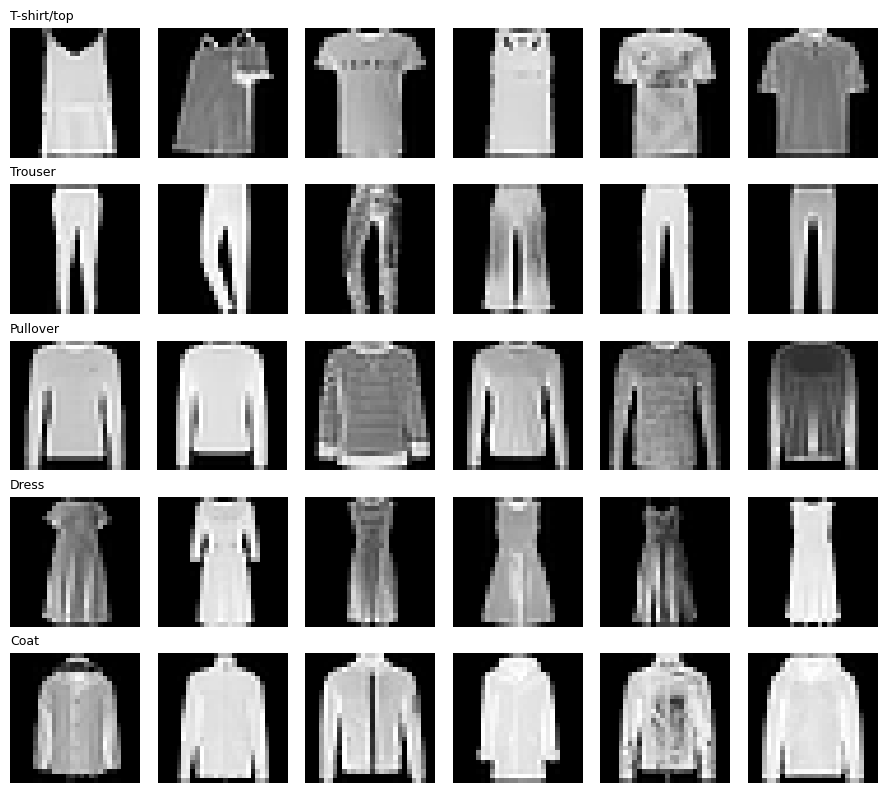

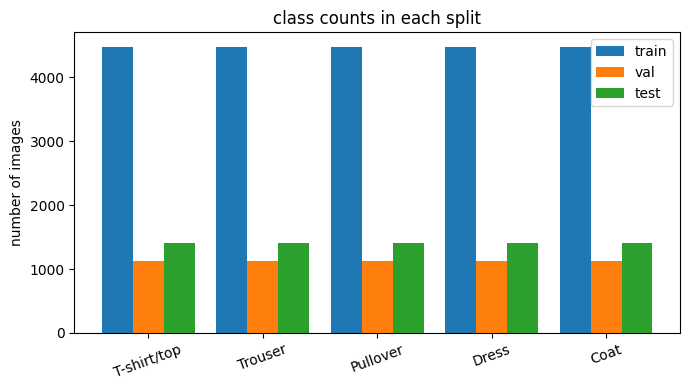

In [4]:
fig, axes = plt.subplots(5, 6, figsize=(9, 8))
for r in range(5):
    imgs = X_train[y_train == r][:6]
    for c in range(6):
        axes[r, c].imshow(imgs[c].reshape(28, 28), cmap="gray")
        axes[r, c].axis("off")
    axes[r, 0].set_title(chosen_names[r], fontsize=9, loc="left")
plt.tight_layout()
plt.savefig("sample_images.png", dpi=120)
plt.show()

counts = np.array([np.bincount(y_train, minlength=5),
                   np.bincount(y_val, minlength=5),
                   np.bincount(y_test, minlength=5)])
x = np.arange(5)
plt.figure(figsize=(7, 4))
for i, nm in enumerate(["train", "val", "test"]):
    plt.bar(x + (i - 1) * 0.27, counts[i], width=0.27, label=nm)
plt.xticks(x, chosen_names, rotation=20)
plt.ylabel("number of images")
plt.title("class counts in each split")
plt.legend()
plt.tight_layout()
plt.savefig("class_counts.png", dpi=120)
plt.show()

In [5]:
# 3 architectures, 3 to 5 hidden layers, different widths
archs = {
    "arch1 (128-64-32)": [128, 64, 32],
    "arch2 (256-128-64-32)": [256, 128, 64, 32],
    "arch3 (256-128-128-64-32)": [256, 128, 128, 64, 32],
}
opt_names = ["sgd", "batch_gd", "momentum", "nag", "rmsprop", "adam"]

LR = 0.001
THRESH = 10e-4

def make_net(hidden):
    layers = []
    prev = 784
    for h in hidden:
        layers.append(nn.Linear(prev, h))
        layers.append(nn.ReLU())
        prev = h
    layers.append(nn.Linear(prev, 5))
    return nn.Sequential(*layers)

def get_opt(name, params):
    if name in ("sgd", "batch_gd"):
        return optim.SGD(params, lr=LR)
    if name == "momentum":
        return optim.SGD(params, lr=LR, momentum=0.9)
    if name == "nag":
        return optim.SGD(params, lr=LR, momentum=0.9, nesterov=True)
    if name == "rmsprop":
        return optim.RMSprop(params, lr=LR, alpha=0.99, eps=1e-8)
    if name == "adam":
        return optim.Adam(params, lr=LR, betas=(0.9, 0.999), eps=1e-8)
    raise ValueError("unknown optimizer " + name)

def predict(model, X):
    model.eval()
    with torch.no_grad():
        out = [model(X[i:i + 5000]).argmax(dim=1) for i in range(0, len(X), 5000)]
    return torch.cat(out)

def acc(model, X, y):
    return 100.0 * (predict(model, X) == y).float().mean().item()

In [6]:
def train(model, opt_name, max_epochs = 100):
    # max_epochs is only a safety net so a run can never loop forever,
    # the real stopping rule is the error difference below
    opt = get_opt(opt_name, model.parameters())
    n = len(Xtr)
    bs = n if opt_name == "batch_gd" else 16
    g = torch.Generator().manual_seed(SEED)    # same shuffling for every optimizer

    losses = []
    for ep in range(max_epochs):
        model.train()
        order = torch.randperm(n, generator=g)
        xs, ys = Xtr[order], ytr[order]
        total = 0.0
        for i in range(0, n, bs):
            xb, yb = xs[i:i + bs], ys[i:i + bs]
            opt.zero_grad()
            loss = F.cross_entropy(model(xb), yb)
            loss.backward()
            opt.step()
            total += loss.item() * len(xb)
        losses.append(total / n)
        print("   epoch", ep + 1, "avg error %.5f" % losses[-1], flush=True)
        if ep > 0 and abs(losses[-1] - losses[-2]) < THRESH:
            break
    return losses

In [7]:
save_file = "runs_quick.pkl" if QUICK else "runs.pkl"
results = {}
if os.path.exists(save_file):
    with open(save_file, "rb") as f:
        results = pickle.load(f)
    print("loaded", len(results), "finished runs from", save_file)

init_weights = {}
for i, (an, hidden) in enumerate(archs.items()):
    set_seed(SEED + i)
    init_weights[an] = copy.deepcopy(make_net(hidden).state_dict())

for an, hidden in archs.items():
    for on in opt_names:
        if (an, on) in results:
            continue
        print(an, "|", on, flush=True)
        net = make_net(hidden)
        net.load_state_dict(init_weights[an])
        t0 = time.time()
        losses = train(net, on)
        results[(an, on)] = {
            "losses": losses,
            "epochs": len(losses),
            "train_acc": acc(net, Xtr, ytr),
            "val_acc": acc(net, Xva, yva),
            "weights": copy.deepcopy(net.state_dict()),
            "seconds": time.time() - t0,
        }
        r = results[(an, on)]
        print("  epochs %d, train acc %.2f, val acc %.2f, %.0fs" % (r["epochs"], r["train_acc"], r["val_acc"], r["seconds"]))
        with open(save_file, "wb") as f:
            pickle.dump(results, f)
print("finished")

arch1 (128-64-32) | sgd
   epoch 1 avg error 1.59925
   epoch 2 avg error 1.53717
   epoch 3 avg error 1.32354
   epoch 4 avg error 1.03792
   epoch 5 avg error 0.86231
   epoch 6 avg error 0.73521
   epoch 7 avg error 0.63185
   epoch 8 avg error 0.56399
   epoch 9 avg error 0.52030
   epoch 10 avg error 0.48806
   epoch 11 avg error 0.46247
   epoch 12 avg error 0.44274
   epoch 13 avg error 0.42747
   epoch 14 avg error 0.41585
   epoch 15 avg error 0.40638
   epoch 16 avg error 0.39879
   epoch 17 avg error 0.39190
   epoch 18 avg error 0.38639
   epoch 19 avg error 0.38176
   epoch 20 avg error 0.37733
   epoch 21 avg error 0.37291
   epoch 22 avg error 0.36882
   epoch 23 avg error 0.36609
   epoch 24 avg error 0.36316
   epoch 25 avg error 0.35969
   epoch 26 avg error 0.35624
   epoch 27 avg error 0.35413
   epoch 28 avg error 0.35077
   epoch 29 avg error 0.34828
   epoch 30 avg error 0.34619
   epoch 31 avg error 0.34316
   epoch 32 avg error 0.34071
   epoch 33 avg error 0.3

,sgd,batch_gd,momentum,nag,rmsprop,adam
arch1 (128-64-32),69,2,33,22,29,25
arch2 (256-128-64-32),65,2,22,22,23,34
arch3 (256-128-128-64-32),69,2,27,27,20,24


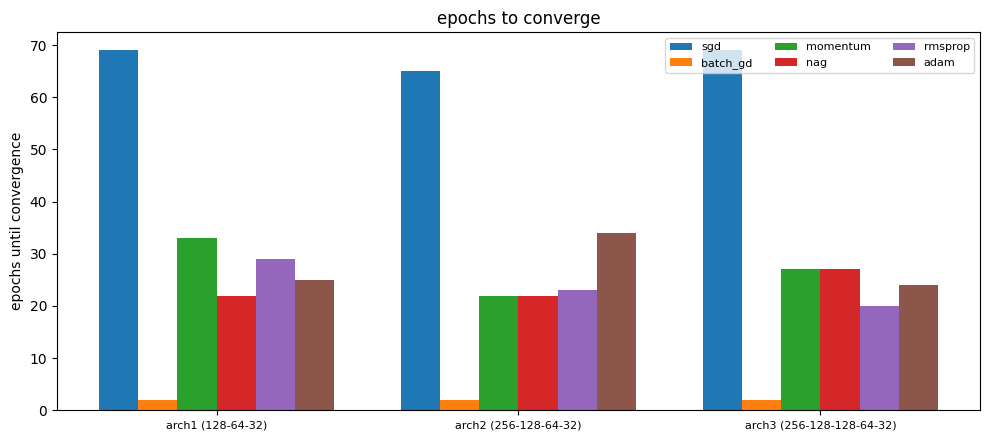

In [8]:
epoch_table = pd.DataFrame({on: [results[(an, on)]["epochs"] for an in archs] for on in opt_names},
                           index=list(archs.keys()))
display(epoch_table)
epoch_table.to_csv("epochs_table.csv")

# bar chart of the same table
plt.figure(figsize=(10, 4.5))
w = 0.13
x = np.arange(len(archs))
for j, on in enumerate(opt_names):
    plt.bar(x + (j - 2.5) * w, epoch_table[on].values, width=w, label=on)
plt.xticks(x, list(archs.keys()), fontsize=8)
plt.ylabel("epochs until convergence")
plt.title("epochs to converge")
plt.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.savefig("epochs_bar.png", dpi=130)
plt.show()

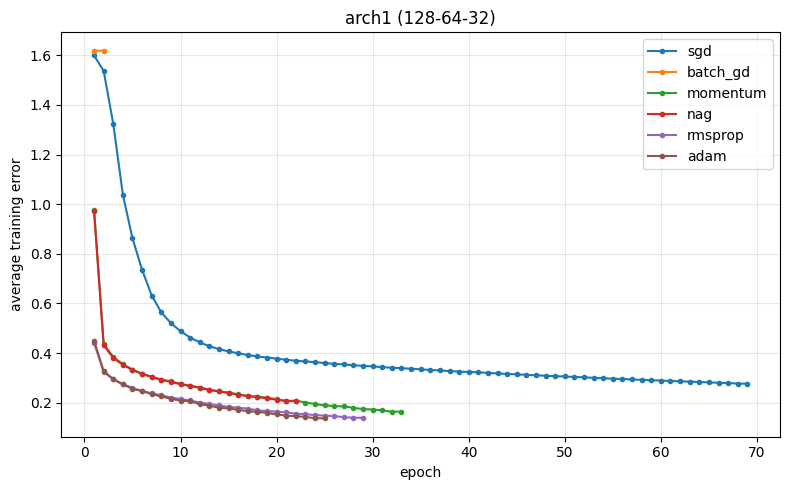

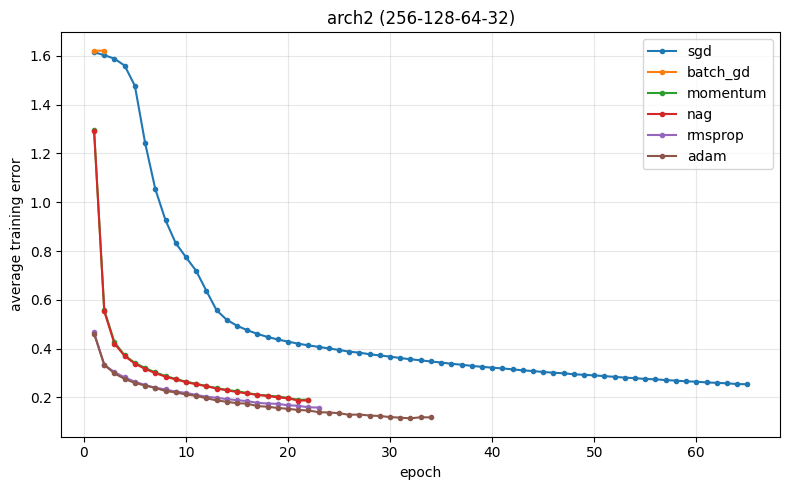

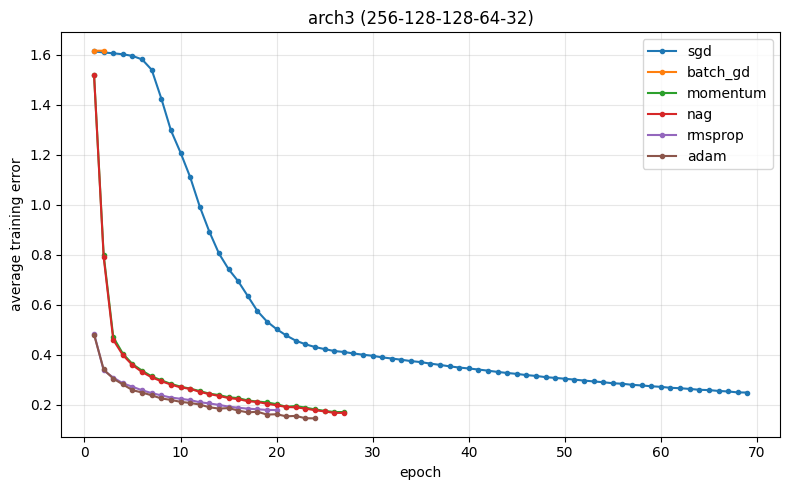

In [9]:
for k, an in enumerate(archs):
    plt.figure(figsize=(8, 5))
    for on in opt_names:
        l = results[(an, on)]["losses"]
        plt.plot(range(1, len(l) + 1), l, marker="o", ms=3, label=on)
    plt.xlabel("epoch")
    plt.ylabel("average training error")
    plt.title(an)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig("loss_arch%d.png" % (k + 1), dpi=130)
    plt.show()

training accuracy (%)


,sgd,batch_gd,momentum,nag,rmsprop,adam
arch1 (128-64-32),90.49,7.91,94.25,92.95,95.14,95.16
arch2 (256-128-64-32),91.39,20.00,92.79,93.60,94.36,95.91
arch3 (256-128-128-64-32),91.62,20.00,94.55,94.67,94.01,94.80


validation accuracy (%)


,sgd,batch_gd,momentum,nag,rmsprop,adam
arch1 (128-64-32),89.39,7.55,91.36,90.57,91.16,91.48
arch2 (256-128-64-32),89.98,20.00,90.11,90.71,91.11,91.09
arch3 (256-128-128-64-32),89.93,20.00,91.61,91.20,91.02,91.05


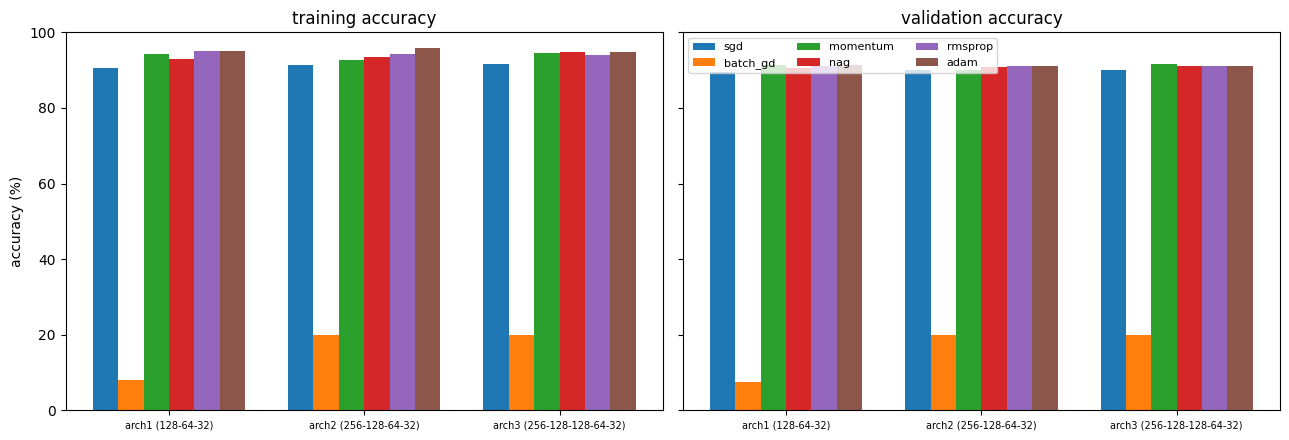

In [10]:
train_table = pd.DataFrame({on: [results[(an, on)]["train_acc"] for an in archs] for on in opt_names},
                           index=list(archs.keys())).round(2)
val_table = pd.DataFrame({on: [results[(an, on)]["val_acc"] for an in archs] for on in opt_names},
                         index=list(archs.keys())).round(2)
print("training accuracy (%)")
display(train_table)
print("validation accuracy (%)")
display(val_table)
train_table.to_csv("train_acc.csv")
val_table.to_csv("val_acc.csv")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, tab, ttl in [(axes[0], train_table, "training accuracy"), (axes[1], val_table, "validation accuracy")]:
    for j, on in enumerate(opt_names):
        ax.bar(x + (j - 2.5) * w, tab[on].values, width=w, label=on)
    ax.set_xticks(x)
    ax.set_xticklabels(list(archs.keys()), fontsize=7)
    ax.set_title(ttl)
    ax.set_ylim(max(0, tab.values.min() - 10), 100)
axes[0].set_ylabel("accuracy (%)")
axes[1].legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.savefig("accuracy_bars.png", dpi=130)
plt.show()

best: arch3 (256-128-128-64-32) with momentum
epochs: 27
train acc: 94.55   val acc: 91.61

train accuracy: 94.55%
             T-shirt/top  Trouser  Pullover  Dress  Coat
T-shirt/top         4294        1        66    115     4
Trouser                1     4400         1     73     5
Pullover              52        0      4114     36   278
Dress                 52        1         9   4317   101
Coat                   1        0       312    113  4054


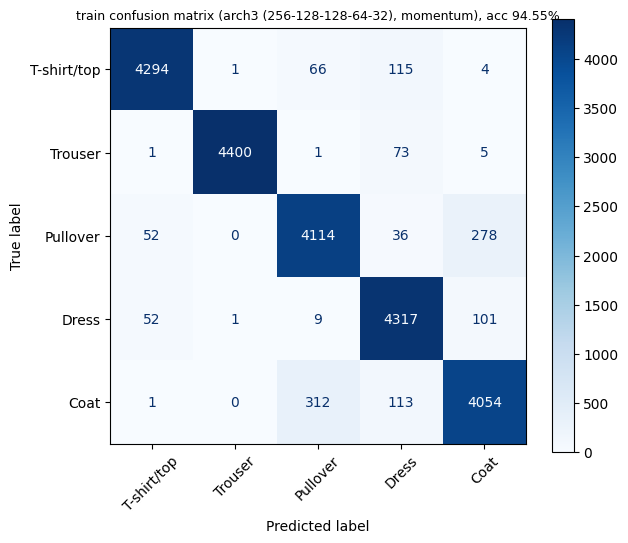


test accuracy: 90.36%
             T-shirt/top  Trouser  Pullover  Dress  Coat
T-shirt/top         1288        0        43     66     3
Trouser                2     1344         4     46     4
Pullover              34        0      1207     17   142
Dress                 42        3         8   1288    59
Coat                   1        1       136     64  1198


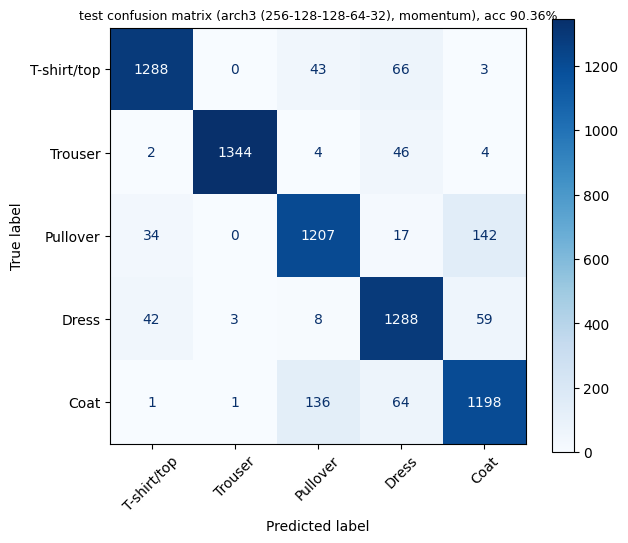

In [11]:
best_key, best_val = None, -1
for key, r in results.items():
    if r["val_acc"] > best_val:
        best_key, best_val = key, r["val_acc"]

best_arch, best_opt = best_key
print("best:", best_arch, "with", best_opt)
print("epochs:", results[best_key]["epochs"])
print("train acc: %.2f   val acc: %.2f" % (results[best_key]["train_acc"], results[best_key]["val_acc"]))

best_net = make_net(archs[best_arch])
best_net.load_state_dict(results[best_key]["weights"])

for nm, Xs, ys in [("train", Xtr, ytr), ("test", Xte, yte)]:
    pred = predict(best_net, Xs).numpy()
    true = ys.numpy()
    cm = confusion_matrix(true, pred, labels=[0, 1, 2, 3, 4])
    a = accuracy_score(true, pred) * 100
    print("\n%s accuracy: %.2f%%" % (nm, a))
    print(pd.DataFrame(cm, index=chosen_names, columns=chosen_names))

    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    ConfusionMatrixDisplay(cm, display_labels=chosen_names).plot(ax=ax, cmap="Blues", xticks_rotation=45)
    ax.set_title("%s confusion matrix (%s, %s), acc %.2f%%" % (nm, best_arch, best_opt, a), fontsize=9)
    plt.tight_layout()
    plt.savefig("confusion_%s.png" % nm, dpi=130)
    plt.show()

T-shirt/top  92.00%
Trouser      96.00%
Pullover     86.21%
Dress        92.00%
Coat         85.57%


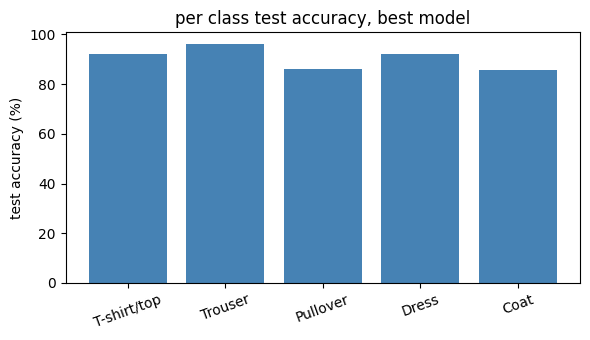

In [12]:
# per class test accuracy of the best model
pred = predict(best_net, Xte).numpy()
per_class = [100.0 * np.mean(pred[y_test == k] == k) for k in range(5)]
for nm, v in zip(chosen_names, per_class):
    print("%-12s %.2f%%" % (nm, v))

plt.figure(figsize=(6, 3.5))
plt.bar(chosen_names, per_class, color="steelblue")
plt.xticks(rotation=20)
plt.ylabel("test accuracy (%)")
plt.title("per class test accuracy, best model")
plt.tight_layout()
plt.savefig("per_class_acc.png", dpi=130)
plt.show()